In [ ]:
import pandas as pd

In [ ]:
df_clean = pd.read_csv('file1.csv')
speech_clean_df = pd.read_csv('file2.csv')

#Document Term Matrix

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

#Stop word removal in transcript column
cv = CountVectorizer(stop_words='english')
data_cv = cv.fit_transform(df_clean.transcript)

In [ ]:
data_dtm = pd.DataFrame(data_cv.toarray(), columns=cv.get_feature_names_out())
data_dtm.index = df_clean.index
data_dtm = data_dtm.iloc[:,:-1]
data_dtm

,aa,aahhhh,aaron,aback,abalthus,abandon,abandoned,abandoning,abandons,abated,...,ôharvestõ,ôi,ômay,ôsobriety,ôtell,ôthe,ôwe,ôwhat,ôyou,ôyouõre
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
318,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
319,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
320,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# Stemming

In [ ]:
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.stem import PorterStemmer
from nltk.stem import LancasterStemmer
from nltk.stem import WordNetLemmatizer
import ssl

try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

nltk.download('punkt')

import spacy

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


In [ ]:
#Create an object of class PorterStemmer
porter = PorterStemmer() #Uses Suffix Stripping (simplicity and speed)
lancaster = LancasterStemmer() #May over-stem

In [ ]:
def stemSentence(text):
    token_words=word_tokenize(text,'english')
    token_words
    stem_sentence=[]
    for word in token_words:
        stem_sentence.append(porter.stem(word))
        stem_sentence.append(" ")
    return "".join(stem_sentence)

In [ ]:
speech_clean_1 = speech_clean_df.copy()
speech_clean_1['transcript'] = speech_clean_df['transcript'].apply(lambda x: stemSentence(x))
speech_clean_1

,Unnamed: 0,speaker,year,transcript,length
0,0,OPRAH WINFREY,1918.0,thank you walli annenberg and a special thank ...,15301.0
1,1,OPRAH WINFREY,2007.0,presid swygert truste distinguish guest my fel...,14168.0
2,2,FRANKLIN D ROOSEVELT,1932.0,for me as for you thi is a day of honor attain...,16017.0
3,3,WILLIAM ALLEN,1936.0,about all that a commenc orat can do for hi au...,14953.0
4,4,CARRIE CHAPMAN,1936.0,i bring a messag to sweet briar colleg and esp...,22942.0
...,...,...,...,...,...
317,317,ROBERT IGER,2021.0,good even presid hartzel chairman eltif member...,13240.0
318,318,KEN JEONG,2022.0,thank you presid fitt provost forman distingui...,10994.0
319,319,JOHN ROTH,2022.0,as you have heard i am a historian after year ...,13648.0
320,320,TAYLOR SWIFT,2022.0,last time i wa in a stadium thi size i wa danc...,14908.0


In [ ]:
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = stopwords.words('english')
speech_clean_1['transcript'] = speech_clean_1['transcript'].apply(lambda x: ' '.join([word for word in x.split() if word not in (stop_words)]))
speech_clean_1

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,Unnamed: 0,speaker,year,transcript,length
0,0,OPRAH WINFREY,1918.0,thank walli annenberg special thank dean willo...,15301.0
1,1,OPRAH WINFREY,2007.0,presid swygert truste distinguish guest fellow...,14168.0
2,2,FRANKLIN D ROOSEVELT,1932.0,thi day honor attain honor confer upon deepli ...,16017.0
3,3,WILLIAM ALLEN,1936.0,commenc orat hi auditor turn face around look ...,14953.0
4,4,CARRIE CHAPMAN,1936.0,bring messag sweet briar colleg especi senior ...,22942.0
...,...,...,...,...,...
317,317,ROBERT IGER,2021.0,good even presid hartzel chairman eltif member...,13240.0
318,318,KEN JEONG,2022.0,thank presid fitt provost forman distinguish f...,10994.0
319,319,JOHN ROTH,2022.0,heard historian year teach know disciplin isnt...,13648.0
320,320,TAYLOR SWIFT,2022.0,last time wa stadium thi size wa danc heel wea...,14908.0


In [ ]:
# Document-Term Matrix
# After stemming: columns...39268 --> 31502
data1_cv = cv.fit_transform(speech_clean_1.transcript)
data_dtm = pd.DataFrame(data1_cv.toarray(), columns=cv.get_feature_names_out())
data_dtm.index = speech_clean_1.index
data_dtm = data_dtm.iloc[:,:-1]
data_dtm

,aa,aahhhh,aaron,aback,abalthu,abandon,abat,abbrevi,abc,abcsbut,...,ôharvestõ,ôi,ômay,ôsobrieti,ôtell,ôthe,ôwe,ôwhat,ôyou,ôyouõr
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
318,0,0,1,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
319,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
320,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
from collections import Counter
from wordcloud import WordCloud

In [ ]:
add_stop_words = ['like','youre','ive','im','really','id','ve','just','dont','thi','wa','you','are','that']

In [ ]:
wordcloud=WordCloud(stopwords=add_stop_words, background_color='white',mode="RGB", width=2000 ,
                    height=1000).generate(' '.join(speech_clean_1['transcript']))

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
def show_word_cloud(cloud):
  plt.figure(figsize = (16, 10))
  plt.imshow(cloud, interpolation='bilinear')
  plt.axis("off")
  plt.show()

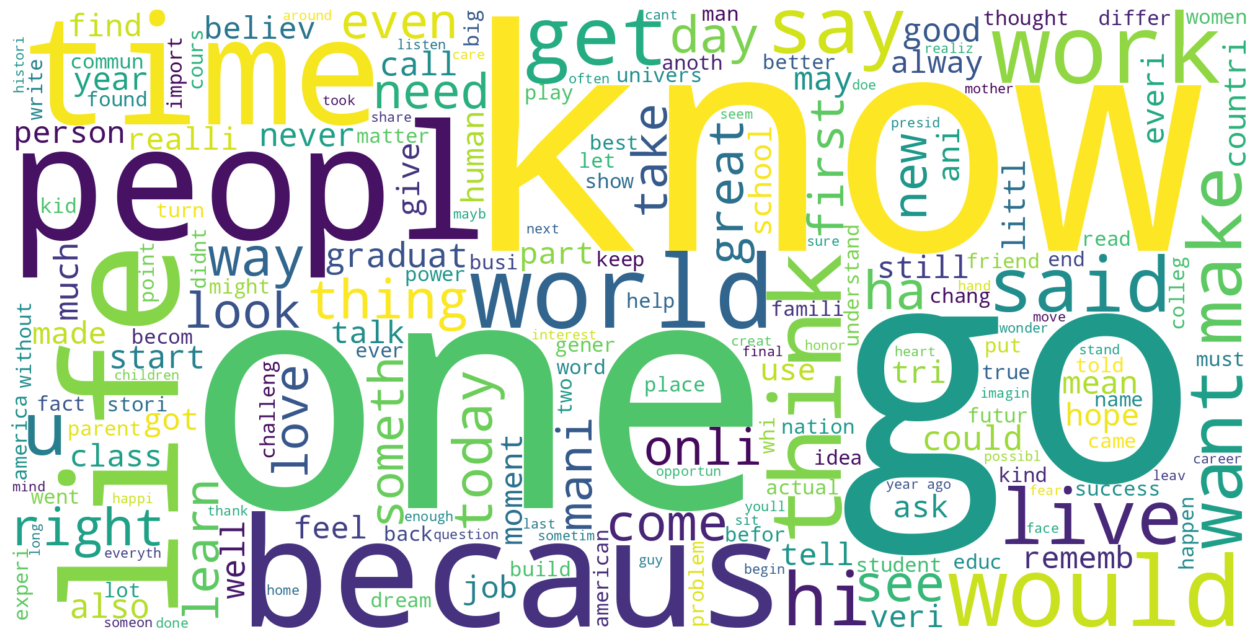

In [ ]:
show_word_cloud(wordcloud)

#Lemmatization with nltk

In [ ]:
from nltk.stem import WordNetLemmatizer

wordnet_lemmatizer = WordNetLemmatizer()

In [ ]:
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
def lemmaSentence(text):
    token_words=word_tokenize(text)
    token_words
    lemma_sentence=[]
    for word in token_words:
        lemma_sentence.append(wordnet_lemmatizer.lemmatize(word, pos="v"))
        lemma_sentence.append(" ")
    return "".join(lemma_sentence)

In [ ]:
speech_clean_2 = speech_clean_df.copy()
speech_clean_2['transcript'] = speech_clean_df['transcript'].apply(lambda x: lemmaSentence(x))
speech_clean_2

,Unnamed: 0,speaker,year,transcript,length
0,0,OPRAH WINFREY,1918.0,thank you wallis annenberg and a special thank...,15301.0
1,1,OPRAH WINFREY,2007.0,president swygert trustees distinguish guests ...,14168.0
2,2,FRANKLIN D ROOSEVELT,1932.0,for me as for you this be a day of honorable a...,16017.0
3,3,WILLIAM ALLEN,1936.0,about all that a commencement orator can do fo...,14953.0
4,4,CARRIE CHAPMAN,1936.0,i bring a message to sweet briar college and e...,22942.0
...,...,...,...,...,...
317,317,ROBERT IGER,2021.0,good even president hartzell chairman eltife m...,13240.0
318,318,KEN JEONG,2022.0,thank you president fitts provost forman disti...,10994.0
319,319,JOHN ROTH,2022.0,as you have hear i be a historian after years ...,13648.0
320,320,TAYLOR SWIFT,2022.0,last time i be in a stadium this size i be dan...,14908.0


In [ ]:
stop_words = stopwords.words('english')
speech_clean_2['transcript'] = speech_clean_2['transcript'].apply(lambda x: ' '.join([word for word in x.split() if word not in (stop_words)]))
speech_clean_2

,Unnamed: 0,speaker,year,transcript,length
0,0,OPRAH WINFREY,1918.0,thank wallis annenberg special thank dean will...,15301.0
1,1,OPRAH WINFREY,2007.0,president swygert trustees distinguish guests ...,14168.0
2,2,FRANKLIN D ROOSEVELT,1932.0,day honorable attainment honor confer upon dee...,16017.0
3,3,WILLIAM ALLEN,1936.0,commencement orator auditors turn face around ...,14953.0
4,4,CARRIE CHAPMAN,1936.0,bring message sweet briar college especially s...,22942.0
...,...,...,...,...,...
317,317,ROBERT IGER,2021.0,good even president hartzell chairman eltife m...,13240.0
318,318,KEN JEONG,2022.0,thank president fitts provost forman distingui...,10994.0
319,319,JOHN ROTH,2022.0,hear historian years teach know discipline isn...,13648.0
320,320,TAYLOR SWIFT,2022.0,last time stadium size dance heel wear glitter...,14908.0


In [ ]:
speech_clean_2.to_csv('lemma.csv')

In [ ]:
data1_cv = cv.fit_transform(speech_clean_2.transcript)
data_dtm = pd.DataFrame(data1_cv.toarray(), columns=cv.get_feature_names_out())
data_dtm.index = speech_clean_2.index
data_dtm = data_dtm.iloc[:,:-1]
data_dtm

,aa,aahhhh,aaron,aback,abalthus,abandon,abate,abbreviations,abc,abcsbut,...,ôharvestõ,ôi,ômay,ôsobriety,ôtell,ôthe,ôwe,ôwhat,ôyou,ôyouõre
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
318,0,0,1,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
319,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
320,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
data_dtm.to_csv('data_dtm_lemma.csv')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
add_stop_words = ['like','youre','ive','im','really','id','ve','just','dont','thi','wa','you','are','that']
wordcloud=WordCloud(stopwords=add_stop_words, background_color='white',mode="RGB", width=2000 ,
                    height=1000).generate(' '.join(speech_clean_2['transcript']))

In [ ]:
def show_word_cloud(cloud):
  plt.figure(figsize = (16, 10))
  plt.imshow(cloud, interpolation='bilinear')
  plt.axis("off")
  plt.show()

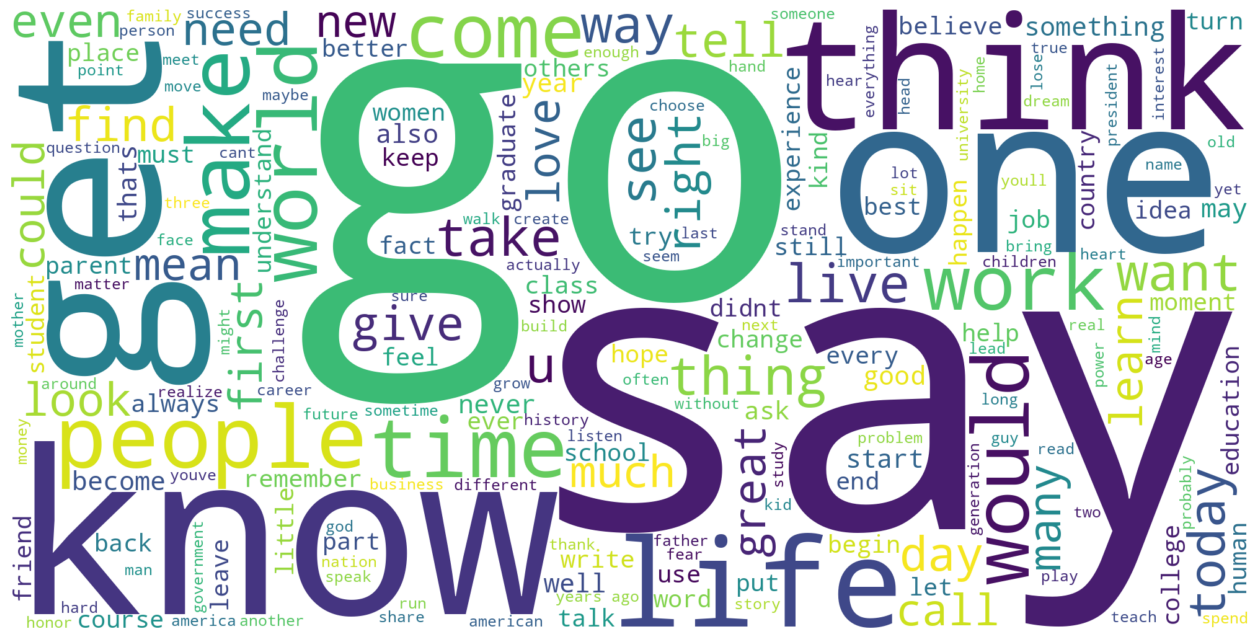

In [ ]:
show_word_cloud(wordcloud)

#Part of Speech Tagging

##Using nltk

In [ ]:
  >>> nltk.download('averaged_perceptron_tagger')
  >>> nltk.download('maxent_ne_chunker')
  >>> nltk.download('words')


In [ ]:
article = speech_clean_2.transcript.iloc[0]

In [ ]:
# Tokenize the article into sentences: sentences
sentences = sent_tokenize(article)

# Tokenize each sentence into words: token_sentences
token_sentences = [word_tokenize(sent) for sent in sentences]

# Tag each tokenized sentence into parts of speech: pos_sentences
pos_sentences = [nltk.pos_tag(sent) for sent in token_sentences]

# Create the named entity chunks: chunked_sentences
chunked_sentences = nltk.ne_chunk_sents(pos_sentences,binary=True)

# Test for stems of the tree with 'NE' tags
for sent in chunked_sentences:
    for chunk in sent:
        if hasattr(chunk, "label") and chunk.label() == "NE":
            print(chunk)

In [ ]:
def pos_nltk(text):

    # Tokenize the article into sentences: sentences
    sentences = sent_tokenize(article)

    # Tokenize each sentence into words: token_sentences
    token_sentences = [word_tokenize(sent) for sent in sentences]

    # Tag each tokenized sentence into parts of speech: pos_sentences
    pos_sentences = [nltk.pos_tag(sent) for sent in token_sentences]

    # Create the named entity chunks: chunked_sentences
    chunked_sentences = nltk.ne_chunk_sents(pos_sentences,binary=True)

    # Test for stems of the tree with 'NE' tags
    for sent in chunked_sentences:
        for chunk in sent:
            if hasattr(chunk, "label") and chunk.label() == "NE":
                print(chunk)

In [ ]:
pos_nltk(article)

##Using spacy

In [ ]:
article = speech_clean_2.transcript.iloc[0] # Test with first transcript
nlp = spacy.load('en_core_web_sm')
doc = nlp(article)

In [ ]:
# Generate pos tags
pos = [(token.text, token.pos_) for token in doc]
pos_df = pd.DataFrame(pos,columns=['word','pos'])
pos_df.head()

,word,pos
0,thank,PROPN
1,wallis,PROPN
2,annenberg,PROPN
3,special,PROPN
4,thank,PROPN


In [ ]:
pos_df.pos.value_counts()

NOUN     489
VERB     318
ADJ      137
PROPN    107
ADV       82
PRON      72
AUX       64
PART      21
DET       16
NUM       15
ADP       15
INTJ       8
PUNCT      4
SCONJ      3
CCONJ      2
Name: pos, dtype: int64

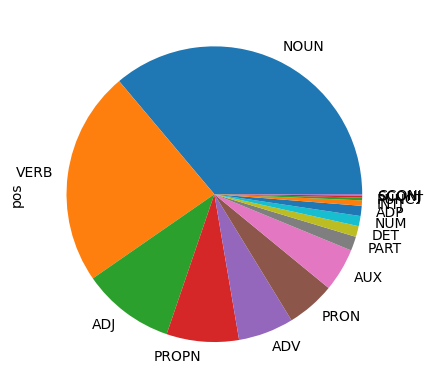

In [ ]:
pos_df.pos.value_counts().plot(kind='pie');

In [ ]:
def pos_pie(article):
    nlp = spacy.load('en_core_web_sm')
    doc = nlp(article)
    pos = [(token.text, token.pos_) for token in doc]
    pos_df = pd.DataFrame(pos,columns=['word','pos'])
    return pos_df.pos.value_counts().plot(kind='pie');

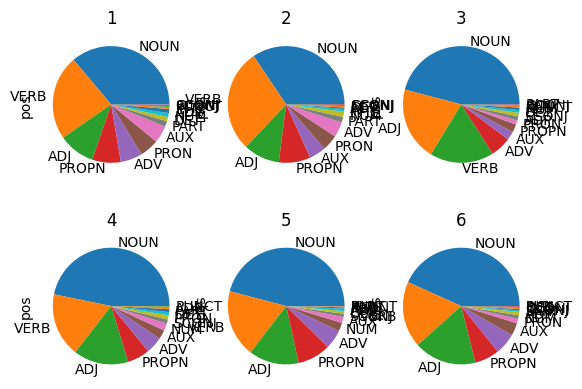

In [ ]:
for index, speech in enumerate(speech_clean_2.transcript.iloc[:6]):
    plt.subplot(2, 3, index+1)
    pos_pie(speech)
    plt.title(index+1)

plt.show()

In [ ]:
# Distribution looks similar among different speeches


#Name entity recogonition (NER)

In [ ]:
# Generte named entities
ne = [(ent.text, ent.label_) for ent in doc.ents]
print(ne)

[('wallis annenberg', 'PERSON'), ('today', 'DATE'), ('one', 'CARDINAL'), ('today', 'DATE'), ('seventh', 'ORDINAL'), ('first year', 'DATE'), ('south africa', 'LOC'), ('thando dlomo', 'PERSON'), ('south africa', 'GPE'), ('hours', 'TIME'), ('today', 'DATE'), ('first', 'ORDINAL'), ('tonight', 'TIME'), ('hysteria hysteria', 'PERSON'), ('years', 'DATE'), ('maya angelou', 'PERSON'), ('today hour half', 'TIME'), ('oprah show', 'PERSON'), ('years', 'DATE'), ('one', 'CARDINAL'), ('miss day', 'DATE'), ('twenty five years', 'DATE'), ('deans', 'NORP'), ('misogyny', 'PRODUCT'), ('one', 'CARDINAL'), ('one', 'CARDINAL'), ('hours day', 'TIME'), ('night', 'TIME'), ('one', 'CARDINAL'), ('south africa', 'GPE'), ('oprah winfrey leadership academy', 'PERSON'), ('million', 'CARDINAL'), ('americans', 'NORP'), ('today', 'DATE'), ('thousands', 'CARDINAL'), ('days', 'DATE'), ('number one', 'CARDINAL'), ('first', 'ORDINAL'), ('barbara walters', 'PERSON'), ('barbara act', 'PERSON'), ('barbara', 'PERSON'), ('barbar

In [ ]:
ne_df = pd.DataFrame(ne,columns=['word','ent'])
ne_df.head()

,word,ent
0,wallis annenberg,PERSON
1,today,DATE
2,one,CARDINAL
3,today,DATE
4,seventh,ORDINAL


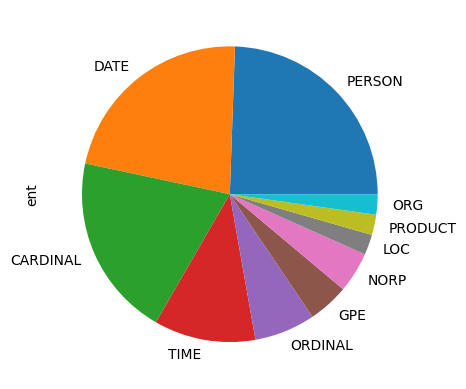

In [ ]:
ne_df.ent.value_counts().plot(kind='pie');

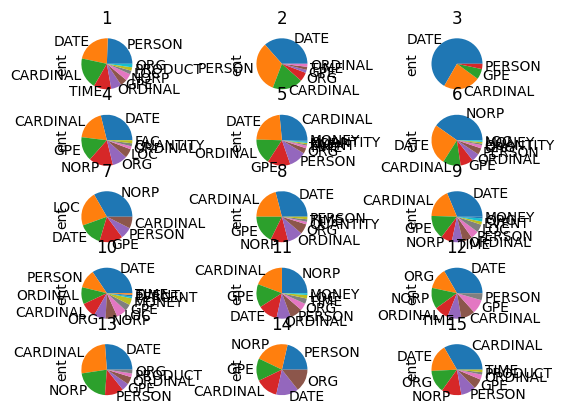

In [ ]:
def ne_pie(article):
    nlp = spacy.load('en_core_web_sm')
    doc = nlp(article)
    ne = [(ent.text, ent.label_) for ent in doc.ents]
    ne_df = pd.DataFrame(ne,columns=['word','ent'])
    return ne_df.ent.value_counts().plot(kind='pie');

for index, speech in enumerate(speech_clean_2.transcript.iloc[:15]):
    plt.subplot(5, 3, index+1)
    ne_pie(speech)
    plt.title(index+1)

plt.show()

In [ ]:
# More variance. May look into this later.

#n-grams

In [ ]:
vectorizer_ng3 = CountVectorizer(ngram_range=(1,3))
data_ng3 = vectorizer_ng3.fit_transform(speech_clean_2.transcript)

In [ ]:
# There are 981298 features now!
data_ng3.shape

(322, 655388)

In [ ]:
# Generate n-grrams upto n=2
vectorizer_ng2 = CountVectorizer(ngram_range=(1,2))
data_ng2 = vectorizer_ng2.fit_transform(speech_clean_1.transcript)

In [ ]:
# There are 328082 features now!
data_ng2.shape

(322, 298939)

In [ ]:
# Document-Term Matrix
# columns: 36167 --> 328082 (~an order of magnitude of difference)
data_dtm = pd.DataFrame(data_ng2.toarray(), columns=vectorizer_ng2.get_feature_names_out())
data_dtm.index = speech_clean_2.index
data_dtm

,aa,aa meet,aahhhh,aahhhh bandaid,aahhhh inhal,aaron,aaron burrstyl,aaron chase,aaron georg,aaron honor,...,ôwe never,ôwhat,ôwhat doe,ôyou,ôyou canõt,ôyou donõt,ôyouõr,ôyouõr suppos,我是一只迷途的羔羊谁能引我走出迷茫哪有我重生的希望噢牧羊人啊噢牧羊人啊,我是一只迷途的羔羊谁能引我走出迷茫哪有我重生的希望噢牧羊人啊噢牧羊人啊 wish
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
318,0,0,0,0,0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
319,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
320,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
